In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import sys  
sys.path.insert(1, '/home/wecapstor1/caph/mppi147h/eROdata')
import eROdata
from eROdata import *
#sys.path.insert(1, '/home/wecapstor1/caph/mppi147h/gammapy-mwl/gammapy-mwl')
#from gammapy_mwl.models.sherpa import SherpaSpectralModel

In [3]:
import sys
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, solar_system, get_body_barycentric, get_body, EarthLocation, AltAz
from astropy.time import Time
from regions import CircleSkyRegion, RectangleSkyRegion
from gammapy.maps import WcsGeom, MapAxis, Map, WcsNDMap
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, FoVBackgroundMaker
from gammapy.data import DataStore
from gammapy.datasets import Datasets, FluxPointsDataset, MapDataset, MapDatasetOnOff
from gammapy.modeling import Fit
from gammapy.modeling.models import SkyModel, LogParabolaSpectralModel, PointSpatialModel, PowerLawSpectralModel, FoVBackgroundModel, Models,ExpCutoffPowerLawSpectralModel, TemplateSpatialModel, NaimaSpectralModel, SpectralModel
from gammapy.estimators import FluxPoints,FluxPointsEstimator, ExcessMapEstimator, TSMapEstimator
from gammapy.visualization import plot_distribution
from gammapy.stats import ts_to_sigma
import naima
import gammapy

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
np.seterr(divide='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Creating a 3D eROSITA dataset:

The basis for any eROSITA data products are the eROSITA event files. Find and download all sky tiles covering your region from https://erosita.mpe.mpg.de/dr1/erodat/skyview/skytile_search/, add them to the basket and download the eventfiles (DR1) or visit https://erosita.mpe.mpg.de/edr/eROSITAObservations/ and select and download your observations (EDR).

It is recommended to use the provided snakemake workflows to create the eROSITA data products (eROSITA_generate_files) or the full dataset (eROSITA_full_dataset).

Snakemake installation in a dedicated environment is easy (see https://snakemake.readthedocs.io/en/stable/getting_started/installation.html) and can make use of the eSASS software via a docker and the appropriate gammapy environment easily. No further installations are then necessary for dataset creation.

All necessary information is supplied in the file `config.py`. See file for detailed description of parameter meanings. The current parameters in `config.py` were used to create the dataset we will look at in the following.

To run the snakemake workflows then use:
```
snakemake -s eROdata_full_dataset --sdm conda
```
To run them on a cluster (recommended), with e.g. SLURM, the arguments ` --executor slurm --default-resources --jobs 100` can be used (see `snakemake` documentation for options). Settings for cluster runtime and memory are included in `config.py`.

Most settings are available in the snakemake workflow, for maximum control the data products can be created and assembled manually.

# Loading a 3D eROSITA dataset into Gammapy:

A 3D eROSITA MapDataset or MapDatasetOnOff can be loaded into Gammapy like any other dataset. The dataset is created in logarithmic interpolation, the function `to_lin()` changes this to linear interpolation.

In [5]:
msh_coord = SkyCoord(ra=228.4821552*u.deg, dec=-59.1375241*u.deg, frame="fk5")
path = "/home/wecapstor1/caph/mppi147h/pwn_analysis/DR1_eROSITA_data/MSH15-52/data_products_snakemake/"
erosita = to_lin(MapDatasetOnOff.read(path+"dataset_stacked.fits.gz",format="gadf",name="erosita")).cutout(msh_coord,0.4*u.deg)

Let's take a first look at our dataset!

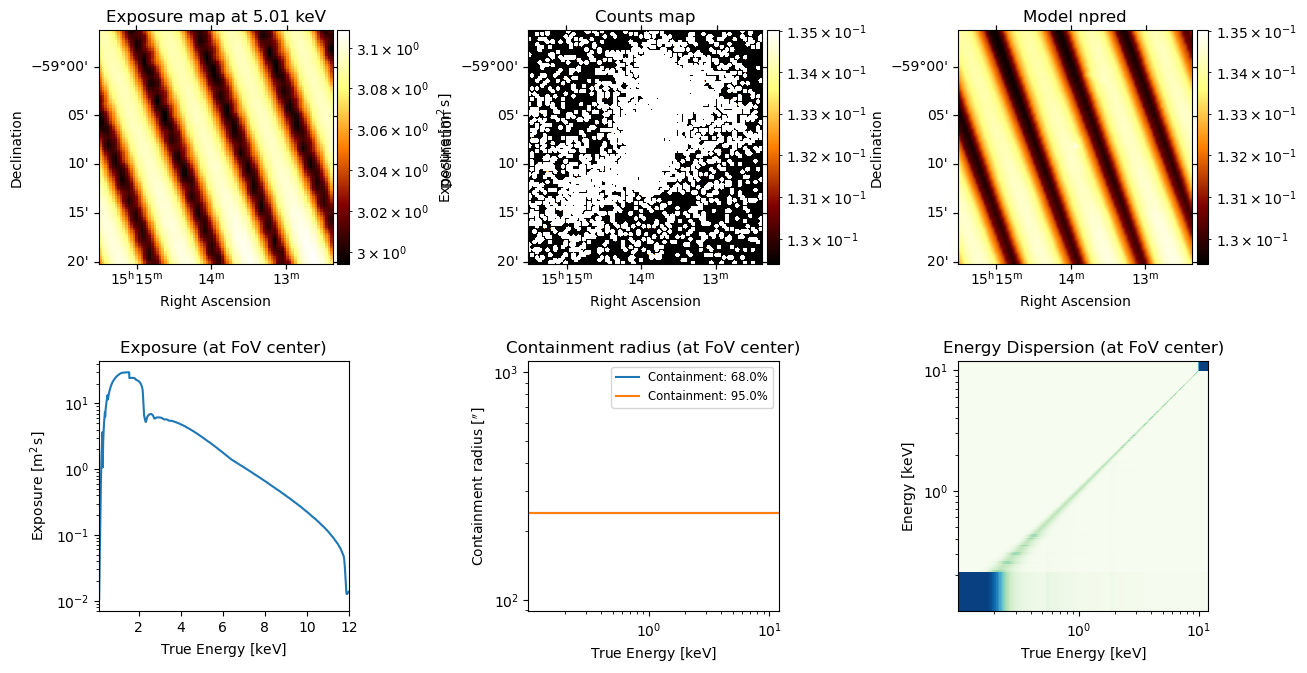

In [6]:
erosita.peek()

The pixel size is a lot smaller than that of gamma-ray instruments, the average spatial resolution is ~26 arcsec. Our data encompasses events from 0.1 to 12.0 keV, the energy range of 0.2 to 9-10.0 keV is generally considered usable. If the eROSITA background model is used, no data below 0.25 keV should be used.

Additionally there are many point sources in the FoV. We define a mask to limit both our energy range and exclude point sources. For point source exclusion the DR1 catalog is used (available under https://erosita.mpe.mpg.de/dr1/AllSkySurveyData_dr1/Catalogues_dr1/, note that different catalogs might apply for EDR data!), the path to which you will need to supply to the function.
Additionally we want to mask out the thermal remnant RCW 89 and the central pulsar by supplying their regions.

In [7]:
mask_erosita=make_exclusion_mask(erosita, catalog_path="/home/wecapstor1/caph/mppi147h/eRASS1_Main/",
                                 include=Regions.parse("fk5;circle(228.4788924,-59.1357402,0.1666666666)", format="ds9"),
                                 exclude=Regions.parse("fk5;circle(228.3789225,-59.0181796,0.0832210) fk5;circle(228.4788924, -59.1357402, 0.0166666666)", format="ds9"))

In [8]:
erosita.mask_safe=mask_erosita
make_energy_mask(erosita, energy_bounds=[0.2,9.0]*u.keV)

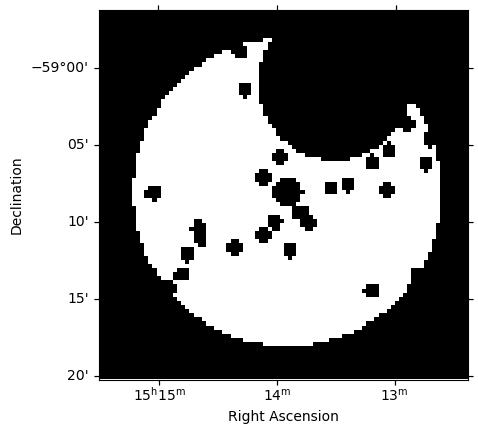

In [9]:
# show a 2D representation of the mask
erosita.mask_image.plot()
None

Now we are ready for a first analysis!

# Fitting a 3D eROSITA dataset:

A look at a significance map already shows us that significant emission is present:

In [10]:
estimator = ExcessMapEstimator(
    correlation_radius="0.01 deg",
    energy_edges = [0.2, 9]*u.keV,
    selection_optional=[],correlate_off=False,)

excessmap_wo_fit = estimator.run(erosita)

/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.1/lib/python3.12/site-packages/gammapy/maps/core.py:1914: RuntimeWarning: invalid value encountered in divide
  out.data = operator(out.data, other_data)


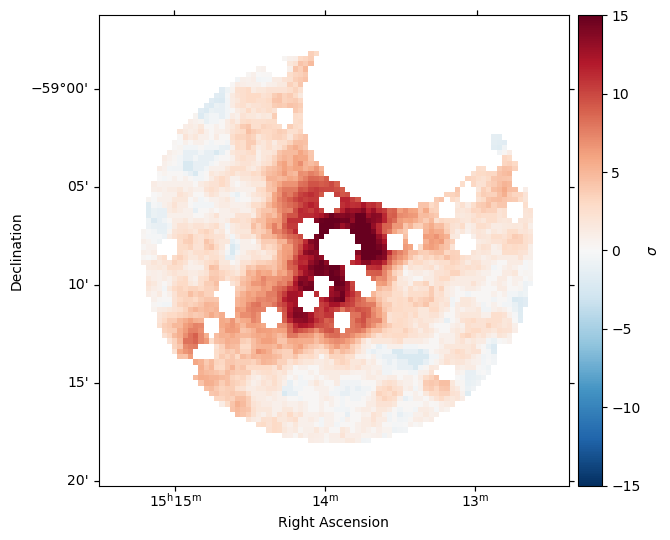

In [11]:
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = excessmap_wo_fit["sqrt_ts"].plot(clim=[-15,15], cmap=plt.cm.RdBu_r,add_cbar=True,kwargs_colorbar={"label" : r"$\sigma$"})

X-ray data up to ~1-2 keV is affected by ISM absorption. To describe this in our model we use the TBabs model (Wilms et al., 2000). ~~To import it into Gammapy we use the SherpaSpectralModel wrapper that is provided in gammapy-mwl (https://github.com/gammapy/gammapy-mwl).~~

Due to an issue in the version provided in the gammapy-mwl repository, a functional version of the SherpaSpectralModel is provided in the eROdata repository. Once the issue is resolved this will be updated.

In [12]:
#sys add path to gammapy_mwl
#from gammapy_mwl.models.sherpa import SherpaSpectralModel
from SherpaSpectralModel import *
from sherpa.astro.xspec import XSTBabs, XSpowerlaw
from sherpa.astro import xspec

In [13]:
xspec.set_xsabund('wilm')
pl_sherpa1 = XSpowerlaw()
pl_sherpa1.PhoIndex = 2.0
pl_sherpa1.norm = 0.05

absorption_sherpa1 = XSTBabs()
absorption_sherpa1.nH = 1.36

spectral_model=SherpaSpectralModel(absorption_sherpa1*pl_sherpa1)

 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).


We define a `SkyModel` using an absorbed powerlaw `SpectralModel` and a 2D Gaussian `SpatialModel` as an approximation for the morphology of MSH 15-52.

In [16]:
spatial_model=GaussianSpatialModel(lon_0=228.4788924*u.deg, lat_0=-59.1357402*u.deg, frame="fk5",sigma=6*u.arcmin,e=0.9,phi=140*u.deg)

spectral_model = spectral_model

source = SkyModel(
    spectral_model=spectral_model,
    spatial_model=spatial_model,
    name="source-gc",
)

source.parameters["lon_0"].min=228.4788924-0.2
source.parameters["lon_0"].max=228.4788924+0.2
source.parameters["lat_0"].min=-59.1357402-0.2
source.parameters["lat_0"].max=-59.1357402+0.2

source.parameters["nH"].frozen=False
source.parameters["nH"].max=1.36
source.parameters["nH"].min=0.0

source.parameters["PhoIndex"].min=1.5
source.parameters["PhoIndex"].max=4.0

source.parameters["e"].frozen=False
source.parameters["phi"].frozen=False

source.parameters["e"].min=0
source.parameters["e"].max=0.9
source.parameters["e"].value=0.8

source.parameters["sigma"].min=4.0

source.parameters["norm"].min=1e-8
source.parameters["norm"].max=1e3

erosita.models=[source]

In [17]:
fit = Fit()
result = fit.run(datasets=[erosita])

print(result)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 671
	total stat : 24223.05

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [18]:
source

SkyModel(spatial_model=<gammapy.modeling.models.spatial.GaussianSpatialModel object at 0x7f9de40f28d0>, spectral_model=<SherpaSpectralModel.SherpaSpectralModel object at 0x7f9dde3f7620>)temporal_model=None)

The fit was a success! We use the `minuit` backend. With more complex X-ray models this can run into problems in which case the `sherpa` backend or a nested sampling approach can help.

A look at the post-fit significance map shows that the excess has been greatly reduced. For a better description of the complex morphology a `TemplateSpatialModel` can be used.

In [19]:
estimator_fit = ExcessMapEstimator(
    correlation_radius="0.01 deg",
    energy_edges = [0.2, 9]*u.keV,
    selection_optional=[],correlate_off=False)

excessmap_fit = estimator_fit.run(erosita)

/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.1/lib/python3.12/site-packages/gammapy/maps/core.py:1914: RuntimeWarning: invalid value encountered in divide
  out.data = operator(out.data, other_data)


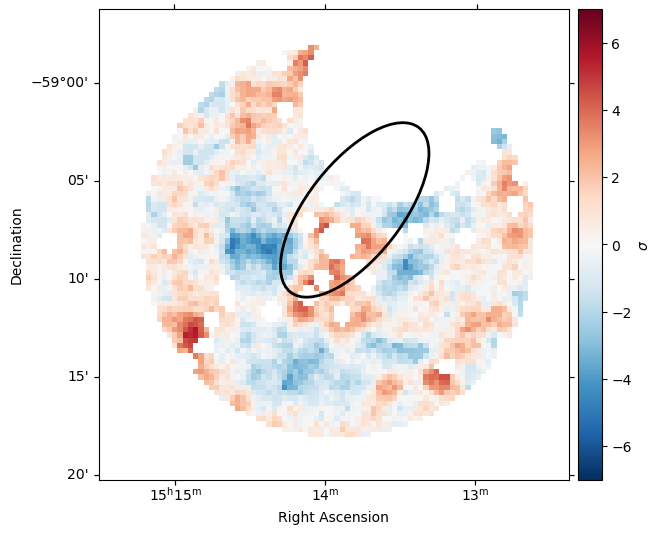

In [20]:
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = excessmap_fit["sqrt_ts"].plot(clim=[-7,7], cmap=plt.cm.RdBu_r,add_cbar=True,kwargs_colorbar={"label" : r"$\sigma$"})
reg=source.spatial_model.to_region().to_pixel(erosita.counts.geom.to_image().wcs)
reg.plot(facecolor='darkblue', linewidth=2, edgecolor='black',ax=ax)
None

Note that due to the data format you should use the `to_spectrum_dataset_xray()` function to extract 1D spectra from 3D eROSITA datasets, such as in the following example.

In [21]:
region=CircleSkyRegion(center=SkyCoord(228.4788924, -59.1357402,unit="deg",frame="icrs"),radius=0.17*u.deg)
spectrum=to_spectrum_dataset_xray(self=erosita,on_region=region)

/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:559: RuntimeWarning: invalid value encountered in divide
  counts_off.data = np.nan_to_num(np.divide(counts_off.data,area_factor.data))
/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:565: RuntimeWarning: invalid value encountered in divide
  acceptance.data = np.nan_to_num(np.divide(acceptance.data,area_factor.data))
/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:572: RuntimeWarning: invalid value encountered in divide
  acceptance_off.data = np.nan_to_num(np.divide(acceptance_off.data,(area_factor.data*area_factor.data)))


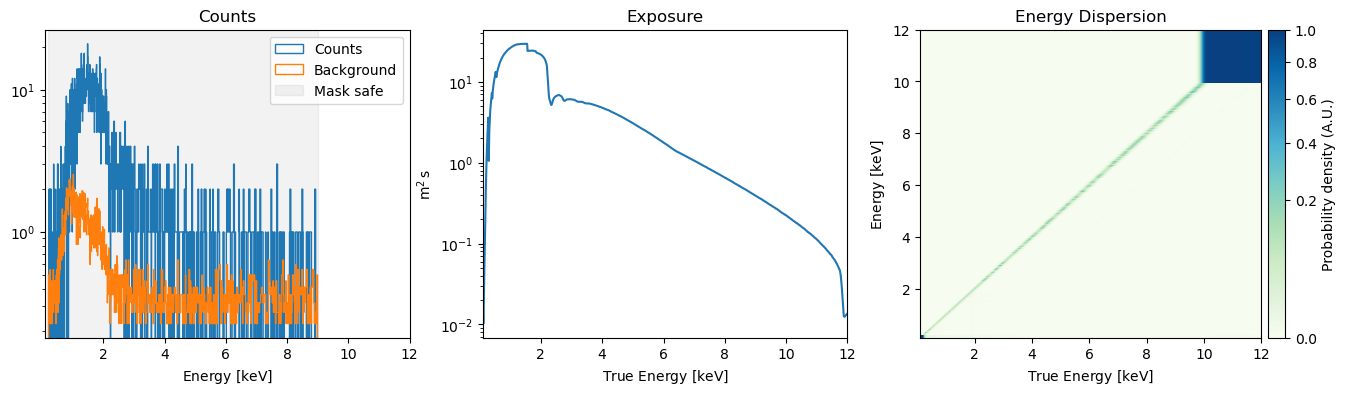

In [22]:
spectrum.peek()

The extracted `spectrum` is a `SpectrumDatasetOnOff` object - a regular energy spectrum with a defined background spectrum.

# Fitting the eROSITA background:

So far we have worked with a `MapDatasetOnOff`, i.e. a dataset in which the background is described by OFF counts. If you would like to model the background instead, working with `MapDataset`s instead is also possible. The background spectra are provided with all created datasets and can be fit to obtain a background model.

`MapDataset`s can directly be created in the `snakemake` pipeline. For illustration purposes, we quickly convert our previous dataset here:

In [23]:
erosita2=erosita.to_map_dataset()
erosita2.background.data = np.zeros_like(erosita2.background.data)

We set the background map to zero, since we are not using a HESS-style background model.

Now we fit the background model on the background spectrum.
The eROSITA background model (Ponti et al. 2023, Yeung et al. 2023) consists of 2 components that need to be treated separately (astrophysical and instrumental/particle background), called `bkg` and `fwc` here. The function `fit_erosita_background()` helps automatize the fitting procedure. Since the background model `bkg` is fairly complex, the `sherpa` backend is used for fitting.

In [24]:
bkg_path = "/home/wecapstor1/caph/mppi147h/pwn_analysis/DR1_eROSITA_data/MSH15-52/data_products_snakemake/"
backgr = to_lin(SpectrumDataset.read(bkg_path+"dataset_stacked_backgr.fits.gz",format="gadf"))

In [25]:
fit_erosita_background(backgr)

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.
 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).
Reading APEC data from 3.0.9



No covariance estimate - not supported by this backend.
No covariance estimate - not supported by this backend.
No covariance estimate - not supported by this backend.
No covariance estimate - not supported by this backend.


OptimizeResult

	backend    : sherpa
	method     : sherpa
	success    : True
	message    : Optimization terminated successfully
	nfev       : 1931
	total stat : -32169.77




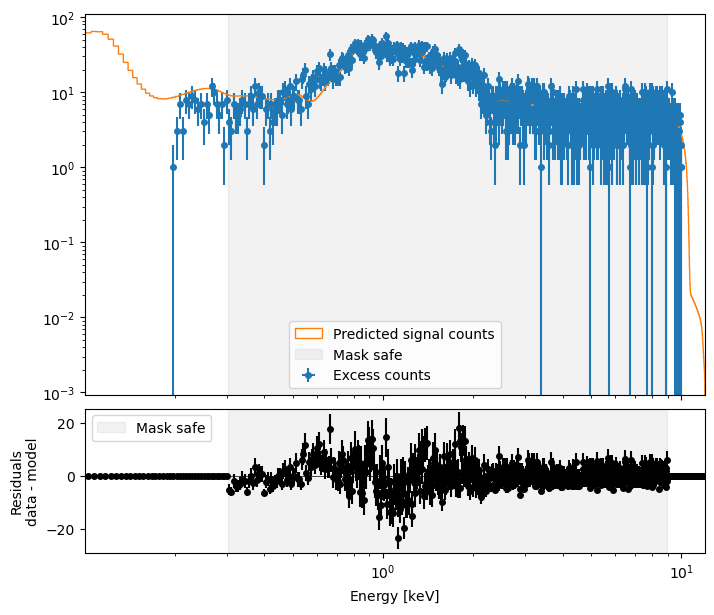

In [26]:
ax = backgr.plot_fit()
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
None

We then export our `bkg` model as a `TemplateSpectralModel` and apply both models to our dataset. We then refit our models.

Both background models are defined with a `ConstantSpatialModel`. Note that this can help separate your background component from the source but presents a slight approximation for the `fwc` component in the DR1 case.

In [27]:
bkg = erosita_background_to_template(backgr.models["manual_bkg"])

In [28]:
erosita2.models = [source.copy(), bkg, backgr.models["fwc"].copy()]

In [29]:
fit2 = Fit()
result2 = fit.run(datasets=[erosita2])

print(result2)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 762
	total stat : 28175.90

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [30]:
erosita2

Since the `fwc` model is not folded with the exposure, it does not have flux units and cannot be plotted along with the other models. Use the `npred` predicted number of counts for visualization instead.

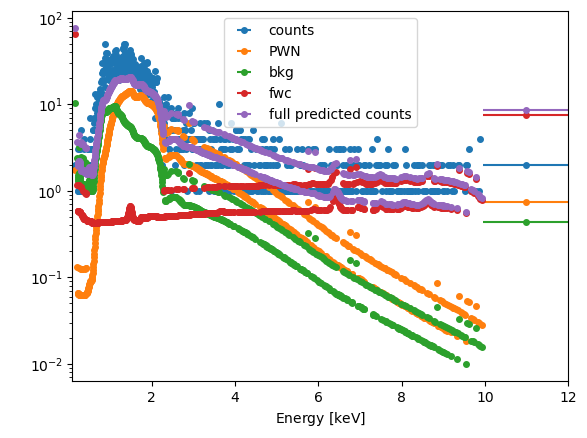

In [31]:
erosita2.counts.get_spectrum().plot(label="counts")
erosita2.npred_signal(model_names=[erosita2.models[0].name]).get_spectrum().plot(label="PWN")
erosita2.npred_signal(model_names=[erosita2.models[1].name]).get_spectrum().plot(label="bkg")
erosita2.npred_signal(model_names=[erosita2.models[2].name]).get_spectrum().plot(label="fwc")
erosita2.npred().get_spectrum().plot(label="full predicted counts")
plt.legend()
None

Exporting and importing a background model from `PyXspec` is also possible with the following functions:

In [ ]:
export_pyxspec_model(filename,name="PyXspec model name") # use this command in PyXspec
model = import_erosita_background_model(filename, fwc=False) # use this command in Gammapy

# Working with regular OGIP spectra:

The OGIP converter provides an easy way of importing regular OGIP-format 1D eROSITA spectra (such as eRASS1 catalog spectra) into Gammapy. This functionality is now also provided by the Gammapy sub-package gammapy-mwl.

In [32]:
from OGIP_converter import *

In [39]:
path_ogip = "/home/wecapstor1/caph/mppi147h/pwn_analysis/DR1_eROSITA_data/MSH15-52/xspec_validation/spectra/src/"
new_energy_axis = OGIP_converter(path_ogip+"msh_820_SourceSpec_grp.fits","_converted")

Files successfully converted!


The `OGIP_converter` returns an energy axis that reflects the grouping of the spectrum. This grouping can be applied to the data with the Gammapy-native function `resample_energy_axis()`.

In [46]:
ogip_reader = gammapy.datasets.OGIPDatasetReader(path_ogip+"msh_820_SourceSpec_grp_converted.fits")
spectrum_ogip = ogip_reader.read()
spectrum_ogip = to_lin(spectrum_ogip.resample_energy_axis(new_energy_axis))

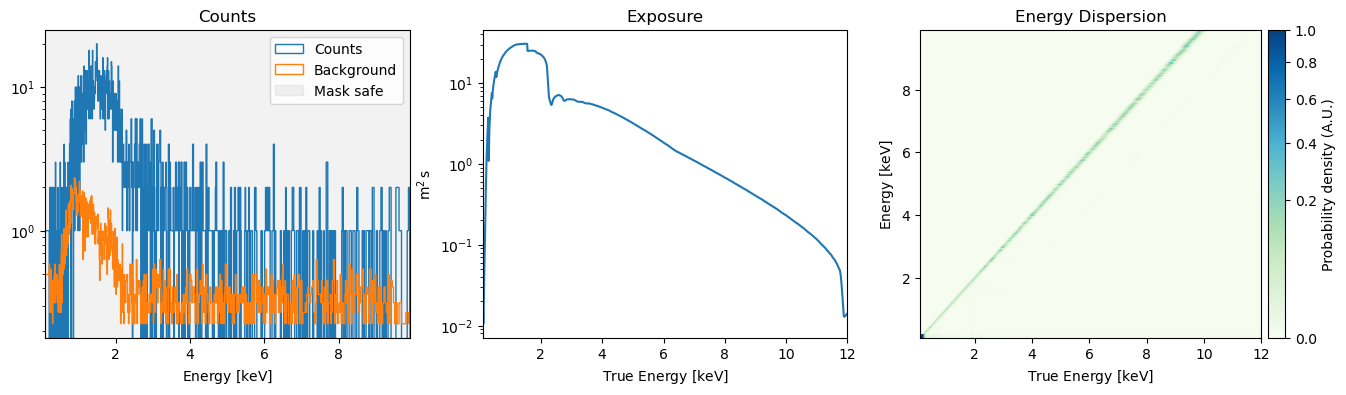

In [47]:
spectrum_ogip.peek()